# Classificação da adesão a depósito bancário

**ATVD-1**

O objetivo é prever se um cliente aderiu (aderiu = sim) comparando k-vizinhos mais próximos, Naive Bayes e regressão logística. A base usada é "bank_marketing_completo.csv", disponível na pasta deste notebook.




# FASE 1 — PREPARAÇÃO

## 1.1 Bibliotecas, semente e leitura da base

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, make_scorer)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

SEED = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [7]:
df= pd.read_csv("bank_marketing_completo.csv")
ALVO = "aderiu"
df.head()

,idade,profissao,estado_civil,escolaridade,inadimplente,financiamento_imobiliario,emprestimo_pessoal,meio_contato,mes,dia_semana,duracao_ligacao_seg,contatos_campanha_atual,dias_desde_ultimo_contato,contatos_anteriores,resultado_campanha_anterior,taxa_variacao_emprego,indice_precos_consumidor,indice_confianca_consumidor,euribor_3m,numero_empregados,aderiu
0,56,empregado_domestico,casado,fundamental_4anos,nao,nao,nao,telefone_fixo,mai,seg,261,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
1,57,servicos,casado,ensino_medio,desconhecido,nao,nao,telefone_fixo,mai,seg,149,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
2,37,servicos,casado,ensino_medio,nao,sim,nao,telefone_fixo,mai,seg,226,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
3,40,administrativo,casado,fundamental_6anos,nao,nao,nao,telefone_fixo,mai,seg,151,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
4,56,servicos,casado,ensino_medio,nao,nao,sim,telefone_fixo,mai,seg,307,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao


## 1.2 Análise exploratória e qualidade dos dados

A variável-alvo é convertida para 0/1 apenas para facilitar as métricas e os classificadores. Valores textuais como desconhecido e inexistente são categorias informativas da própria base, não valores ausentes, portanto permanecem explícitos.

In [8]:
mapeamento_alvo = {"nao": 0, "sim": 1}
valores_alvo = set(df[ALVO].dropna().astype(str).str.lower().unique())
if not valores_alvo.issubset(mapeamento_alvo):
    raise ValueError(f"Valores inesperados em {ALVO}: {valores_alvo - set(mapeamento_alvo)}")
df["aderiu_bin"] = df[ALVO].astype(str).str.lower().map(mapeamento_alvo)


In [9]:
print(f"Dimensões: {df.shape[0]:,} linhas × {df.shape[1] - 1:,} atributos, além da coluna auxiliar do alvo.")
print("\nTipos de dados:")
display(df.drop(columns="aderiu_bin").dtypes.rename("tipo").to_frame())

qualidade = pd.DataFrame({
    "ausentes": df.drop(columns="aderiu_bin").isna().sum(),
    "% ausentes": (df.drop(columns="aderiu_bin").isna().mean() * 100).round(2),
    "valores distintos": df.drop(columns="aderiu_bin").nunique(dropna=False),
})

Dimensões: 41,188 linhas × 21 atributos, além da coluna auxiliar do alvo.

Tipos de dados:


,tipo
idade,int64
profissao,object
estado_civil,object
escolaridade,object
inadimplente,object
financiamento_imobiliario,object
emprestimo_pessoal,object
meio_contato,object
mes,object
dia_semana,object


In [10]:
print("\nQualidade dos dados:")
display(qualidade)
print(f"Linhas totalmente duplicadas: {df.drop(columns='aderiu_bin').duplicated().sum():,}")

categoricas = df.drop(columns=[ALVO, "aderiu_bin"]).select_dtypes(include=["object", "category"]).columns
resumo_desconhecidos = {
    coluna: int(df[coluna].astype(str).str.lower().isin(["desconhecido", "unknown"]).sum())
    for coluna in categoricas
    if df[coluna].astype(str).str.lower().isin(["desconhecido", "unknown"]).any()
}


Qualidade dos dados:


,ausentes,% ausentes,valores distintos
idade,0,0.0,78
profissao,0,0.0,12
estado_civil,0,0.0,4
escolaridade,0,0.0,8
inadimplente,0,0.0,3
financiamento_imobiliario,0,0.0,3
emprestimo_pessoal,0,0.0,3
meio_contato,0,0.0,2
mes,0,0.0,10
dia_semana,0,0.0,5


Linhas totalmente duplicadas: 12


In [11]:
print("\nOcorrências explícitas de 'desconhecido'/'unknown':", resumo_desconhecidos or "nenhuma")
print("\nResumo estatístico dos atributos numéricos:")
display(df.drop(columns=[ALVO, "aderiu_bin"]).select_dtypes(include=np.number).describe().T)

distribuicao_alvo = df[ALVO].value_counts(dropna=False).rename_axis(ALVO).to_frame("quantidade")
distribuicao_alvo["proporcao_%"] = (distribuicao_alvo["quantidade"] / len(df) * 100).round(2)
display(distribuicao_alvo)


Ocorrências explícitas de 'desconhecido'/'unknown': {'profissao': 330, 'estado_civil': 80, 'escolaridade': 1731, 'inadimplente': 8597, 'financiamento_imobiliario': 990, 'emprestimo_pessoal': 990}

Resumo estatístico dos atributos numéricos:


,count,mean,std,min,25%,50%,75%,max
idade,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duracao_ligacao_seg,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
contatos_campanha_atual,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
dias_desde_ultimo_contato,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
contatos_anteriores,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
taxa_variacao_emprego,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
indice_precos_consumidor,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
indice_confianca_consumidor,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor_3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
numero_empregados,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


,quantidade,proporcao_%
aderiu,,
nao,36548,88.73
sim,4640,11.27


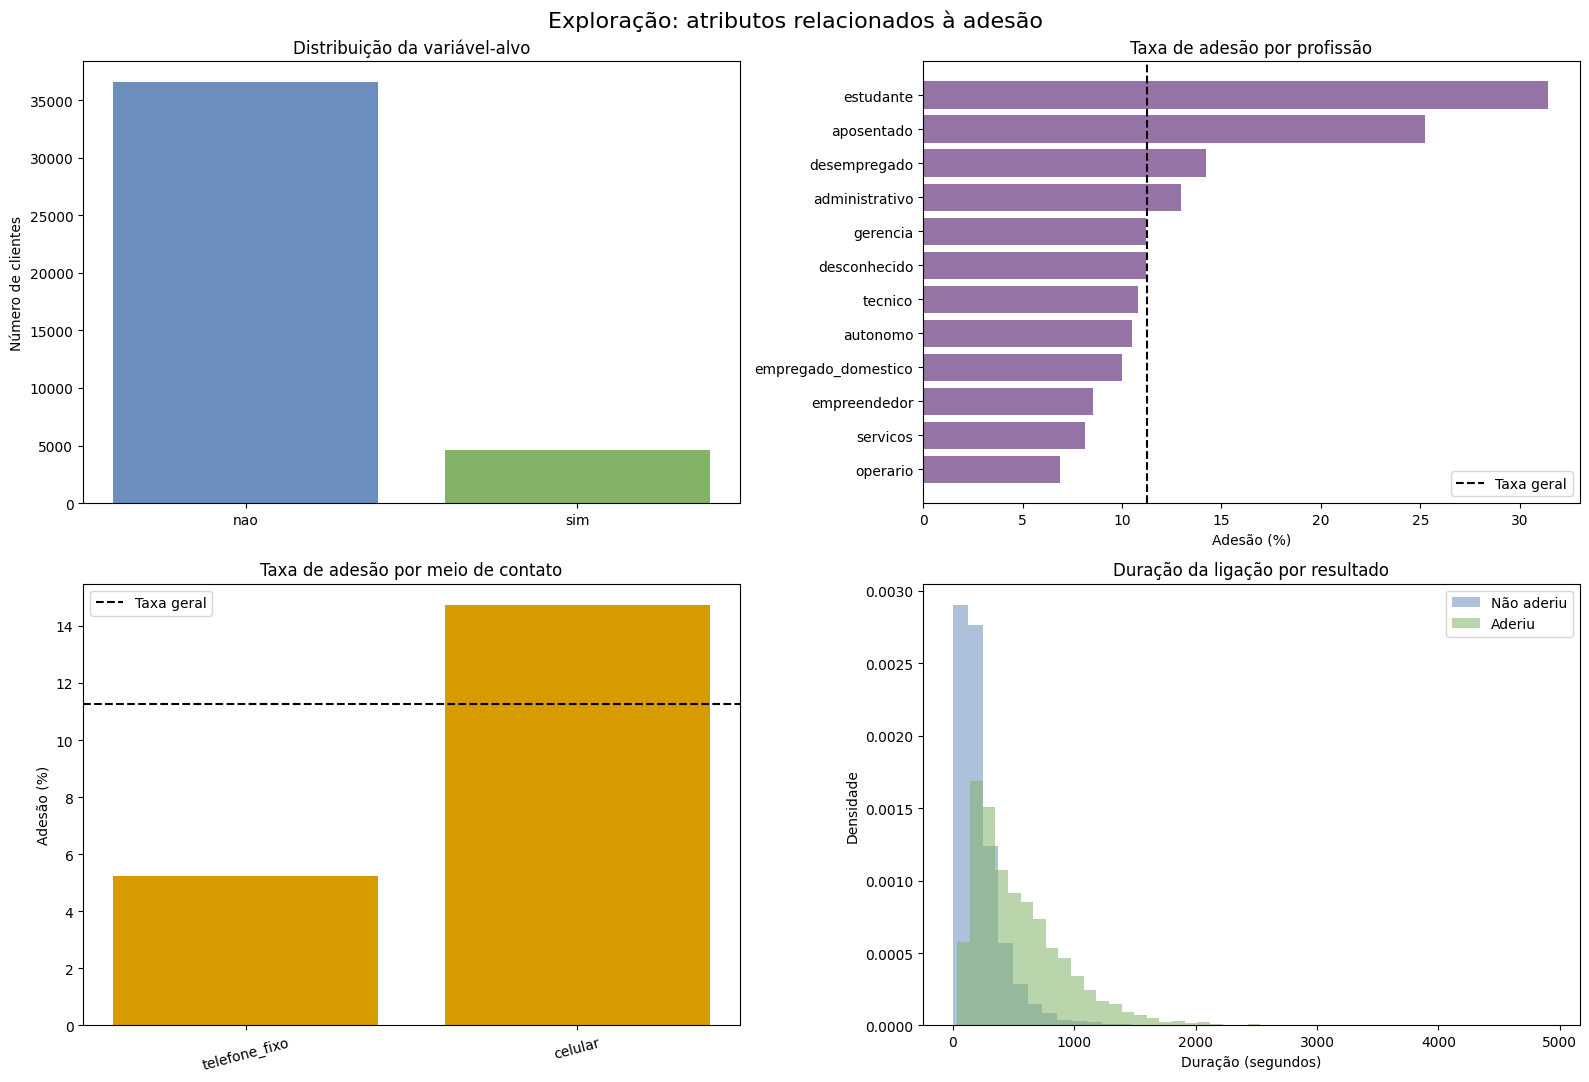


Taxa geral de adesão: 11.3%. A classe positiva é minoritária; acurácia isolada pode ser enganosa.


In [12]:
taxa_alvo = df["aderiu_bin"].mean()
fig, eixos = plt.subplots(2, 2, figsize=(16, 11))

contagens = df[ALVO].value_counts().reindex(["nao", "sim"])
eixos[0, 0].bar(contagens.index, contagens.values, color=["#6c8ebf", "#82b366"])
eixos[0, 0].set_title("Distribuição da variável-alvo")
eixos[0, 0].set_ylabel("Número de clientes")

taxa_profissao = df.groupby("profissao", observed=True)["aderiu_bin"].mean().sort_values()
eixos[0, 1].barh(taxa_profissao.index, taxa_profissao.values * 100, color="#9673a6")
eixos[0, 1].axvline(taxa_alvo * 100, color="black", linestyle="--", label="Taxa geral")
eixos[0, 1].set_title("Taxa de adesão por profissão")
eixos[0, 1].set_xlabel("Adesão (%)")
eixos[0, 1].legend()

taxa_contato = df.groupby("meio_contato", observed=True)["aderiu_bin"].mean().sort_values()
eixos[1, 0].bar(taxa_contato.index, taxa_contato.values * 100, color="#d79b00")
eixos[1, 0].axhline(taxa_alvo * 100, color="black", linestyle="--", label="Taxa geral")
eixos[1, 0].set_title("Taxa de adesão por meio de contato")
eixos[1, 0].set_ylabel("Adesão (%)")
eixos[1, 0].tick_params(axis="x", rotation=15)
eixos[1, 0].legend()

for classe, rotulo, cor in [(0, "Não aderiu", "#6c8ebf"), (1, "Aderiu", "#82b366")]:
    valores = df.loc[df["aderiu_bin"] == classe, "duracao_ligacao_seg"]
    eixos[1, 1].hist(valores, bins=40, alpha=0.55, density=True, label=rotulo, color=cor)
eixos[1, 1].set_title("Duração da ligação por resultado")
eixos[1, 1].set_xlabel("Duração (segundos)")
eixos[1, 1].set_ylabel("Densidade")
eixos[1, 1].legend()

fig.suptitle("Exploração: atributos relacionados à adesão", fontsize=16)
fig.tight_layout()
plt.show()
print(f"\nTaxa geral de adesão: {taxa_alvo:.1%}. A classe positiva é minoritária; acurácia isolada pode ser enganosa.")

## 1.3 Cenários e preparação dos dados

**Cenário principal (operacional):** exclui duracao_ligacao_seg, que só é conhecida depois da ligação e tem vazamento direto do resultado, e também contatos_campanha_atual, meio_contato, mes e dia_semana, que descrevem a campanha/contato recorrente, não o cadastro do cliente antes de selecioná-lo. Mantém atributos cadastrais, histórico de contatos anteriores e contexto econômico, assumidos disponíveis no momento da decisão.

**Cenário completo:** usa todos os atributos, exceto o alvo aderiu, como análise de comparação. Seu desempenho pode ser otimista por incluir informação posterior à decisão.

Não removemos linhas duplicadas nem categorias desconhecidas: a base não fornece identificador único para confirmar duplicação indevida, e esses valores categóricos podem carregar informação. Valores ausentes reais são imputados dentro dos pipelines; numéricos são padronizados e categóricos passam por one-hot encoding. Assim, cada transformação é ajustada apenas nos dados de treino de cada partição.

In [13]:
COLUNAS_EXCLUIDAS_PRINCIPAL = [
    "duracao_ligacao_seg",
    "contatos_campanha_atual",
    "meio_contato",
    "mes",
    "dia_semana",
]
colunas_principal = [
    coluna for coluna in df.columns
    if coluna not in [ALVO, "aderiu_bin", *COLUNAS_EXCLUIDAS_PRINCIPAL]
]
colunas_completo = [coluna for coluna in df.columns if coluna not in [ALVO, "aderiu_bin"]]
print("Exclusões no cenário principal:", COLUNAS_EXCLUIDAS_PRINCIPAL)
print(f"Atributos: principal={len(colunas_principal)}, completo={len(colunas_completo)}")

X = df[colunas_completo].copy()
y = df["aderiu_bin"].astype(int)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
print(f"Treino: {X_treino.shape[0]:,} linhas | Teste reservado: {X_teste.shape[0]:,} linhas")

def criar_preprocessador(X_referencia):
    colunas_num = X_referencia.select_dtypes(include=np.number).columns.tolist()
    colunas_cat = X_referencia.select_dtypes(exclude=np.number).columns.tolist()
    transformadores = []
    if colunas_num:
        pipeline_num = Pipeline([
            ("imputacao", SimpleImputer(strategy="median")),
            ("escala", StandardScaler()),
        ])
        transformadores.append(("numericas", pipeline_num, colunas_num))
    if colunas_cat:
        pipeline_cat = Pipeline([
            ("imputacao", SimpleImputer(strategy="most_frequent")),
            ("codificacao", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ])
        transformadores.append(("categoricas", pipeline_cat, colunas_cat))
    return ColumnTransformer(transformadores, remainder="drop", verbose_feature_names_out=False)

def criar_pipeline(X_referencia, estimador):
    return Pipeline([
        ("preparacao", criar_preprocessador(X_referencia)),
        ("modelo", estimador),
    ])

TAMANHO_AMOSTRA_CV = min(8_000, len(X_treino))
X_cv, _, y_cv, _ = train_test_split(
    X_treino, y_treino, train_size=TAMANHO_AMOSTRA_CV,
    random_state=SEED, stratify=y_treino
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scorer_f1 = make_scorer(f1_score, pos_label=1, zero_division=0)
print(f"Validação cruzada: 5 partições estratificadas sobre {len(X_cv):,} registros de treino.")

Exclusões no cenário principal: ['duracao_ligacao_seg', 'contatos_campanha_atual', 'meio_contato', 'mes', 'dia_semana']
Atributos: principal=15, completo=20
Treino: 28,831 linhas | Teste reservado: 12,357 linhas
Validação cruzada: 5 partições estratificadas sobre 8,000 registros de treino.


# FASE 2 — TREINO E SELEÇÃO

A métrica de seleção é o **F1 da classe aderiu = sim**: com adesão minoritária, ele equilibra a proporção de clientes indicados que aderem (precisão) e a proporção dos aderentes encontrados (recall). A busca usa apenas validação cruzada no treino. Após padronização e one-hot encoding, há atributos numéricos contínuos e atributos categóricos binários: GaussianNB modela entradas contínuas e BernoulliNB representa naturalmente indicadores binários. Por isso, comparamos ambas as variantes por F1 médio em validação cruzada e escolhemos a melhor em cada cenário. Para k-NN, testamos valores ímpares de k (5, 11 e 21), evitando empates simples e cobrindo vizinhanças de tamanhos distintos. Para regressão logística, testamos C em escala logarítmica (0,01 a 10), que controla inversamente a regularização. A escolha é feita pela mesma validação cruzada, sem consultar o teste.

In [14]:
cenarios = {
    "Principal": colunas_principal,
    "Completo": colunas_completo,
}
modelos_finais = {nome: {} for nome in cenarios}
selecao = {nome: {} for nome in cenarios}

## 2.1 k-vizinhos mais próximos (k-NN)

A busca escolhe k por F1 da classe aderente, com cinco partições estratificadas. O processo fica em três chunks: busca, leitura do resultado e ajuste final com todo o conjunto de treino.

In [15]:
for nome_cenario, colunas in cenarios.items():
    X_treino_cenario = X_treino[colunas]
    X_cv_cenario = X_cv[colunas]
    busca_knn = GridSearchCV(
        criar_pipeline(X_cv_cenario, KNeighborsClassifier()),
        param_grid={"modelo__n_neighbors": [5, 11, 21]},
        scoring=scorer_f1, cv=cv, n_jobs=1, refit=False, error_score="raise",
    )
    busca_knn.fit(X_cv_cenario, y_cv)
    idx = busca_knn.best_index_
    estimador_knn = KNeighborsClassifier(
        n_neighbors=busca_knn.best_params_["modelo__n_neighbors"]
    )
    selecao[nome_cenario]["k-NN"] = {
        "estimador": estimador_knn,
        "parametros": busca_knn.best_params_,
        "cv_media": busca_knn.cv_results_["mean_test_score"][idx],
        "cv_dp": busca_knn.cv_results_["std_test_score"][idx],
    }
    print(f"Busca concluída para o cenário {nome_cenario}.")

Busca concluída para o cenário Principal.
Busca concluída para o cenário Completo.


### k-NN — conferir k e validação cruzada


In [16]:
for nome_cenario in cenarios:
    detalhes = selecao[nome_cenario]["k-NN"]
    print(f"{nome_cenario}: k={detalhes['estimador'].n_neighbors}, "
          f"F1 CV={detalhes['cv_media']:.4f} (DP={detalhes['cv_dp']:.4f})")

Principal: k=5, F1 CV=0.3258 (DP=0.0134)
Completo: k=11, F1 CV=0.4653 (DP=0.0213)


### k-NN — todo o treino


In [17]:
for nome_cenario, colunas in cenarios.items():
    X_treino_cenario = X_treino[colunas]
    modelo_final = criar_pipeline(
        X_treino_cenario,
        selecao[nome_cenario]["k-NN"]["estimador"],
    )
    modelo_final.fit(X_treino_cenario, y_treino)
    modelos_finais[nome_cenario]["k-NN"] = modelo_final
    print(f"Modelo k-NN ajustado no treino completo: {nome_cenario}.")

Modelo k-NN ajustado no treino completo: Principal.
Modelo k-NN ajustado no treino completo: Completo.


## 2.2 Regressão logística

O parâmetro C, inverso da força de regularização, é selecionado em escala logarítmica por validação cruzada estratificada. O modelo também está organizado em chunks de busca, leitura do resultado e ajuste final.

In [18]:
for nome_cenario, colunas in cenarios.items():
    X_treino_cenario = X_treino[colunas]
    X_cv_cenario = X_cv[colunas]
    busca_logistica = GridSearchCV(
        criar_pipeline(
            X_cv_cenario,
            LogisticRegression(max_iter=2000, random_state=SEED),
        ),
        param_grid={"modelo__C": [0.01, 0.1, 1.0, 10.0]},
        scoring=scorer_f1, cv=cv, n_jobs=1, refit=False, error_score="raise",
    )
    busca_logistica.fit(X_cv_cenario, y_cv)
    idx = busca_logistica.best_index_
    estimador_logistica = LogisticRegression(
        C=busca_logistica.best_params_["modelo__C"],
        max_iter=2000,
        random_state=SEED,
    )
    selecao[nome_cenario]["Regressão logística"] = {
        "estimador": estimador_logistica,
        "parametros": busca_logistica.best_params_,
        "cv_media": busca_logistica.cv_results_["mean_test_score"][idx],
        "cv_dp": busca_logistica.cv_results_["std_test_score"][idx],
    }
    print(f"Busca concluída para o cenário {nome_cenario}.")

Busca concluída para o cenário Principal.
Busca concluída para o cenário Completo.


### Regressão logística — conferir C e validação cruzada

In [19]:
for nome_cenario in cenarios:
    detalhes = selecao[nome_cenario]["Regressão logística"]
    print(f"{nome_cenario}: C={detalhes['estimador'].C}, "
          f"F1 CV={detalhes['cv_media']:.4f} (DP={detalhes['cv_dp']:.4f})")

Principal: C=10.0, F1 CV=0.3006 (DP=0.0169)
Completo: C=10.0, F1 CV=0.5142 (DP=0.0249)


### Regressão logística — ajustar com todo o treino

In [20]:
for nome_cenario, colunas in cenarios.items():
    X_treino_cenario = X_treino[colunas]
    modelo_final = criar_pipeline(
        X_treino_cenario,
        selecao[nome_cenario]["Regressão logística"]["estimador"],
    )
    modelo_final.fit(X_treino_cenario, y_treino)
    modelos_finais[nome_cenario]["Regressão logística"] = modelo_final
    print(f"Modelo de regressão logística ajustado no treino completo: {nome_cenario}.")

Modelo de regressão logística ajustado no treino completo: Principal.
Modelo de regressão logística ajustado no treino completo: Completo.


## 2.3 Naive Bayes

Comparamos GaussianNB e BernoulliNB por F1 médio no mesmo protocolo de validação. GaussianNB acomoda atributos numéricos contínuos; BernoulliNB é apropriado para os indicadores binários produzidos pelo one-hot encoding. O fluxo fica em três chunks: comparação, leitura dos resultados e ajuste final da variante escolhida.

In [21]:
for nome_cenario, colunas in cenarios.items():
    X_treino_cenario = X_treino[colunas]
    X_cv_cenario = X_cv[colunas]
    variantes_nb = {
        "GaussianNB": GaussianNB(),
        "BernoulliNB": BernoulliNB(alpha=1.0, binarize=0.0),
    }
    resultados_nb = {}
    for nome_variante, estimador in variantes_nb.items():
        scores = cross_val_score(
            criar_pipeline(X_cv_cenario, estimador),
            X_cv_cenario,
            y_cv,
            scoring=scorer_f1,
            cv=cv,
            n_jobs=1,
        )
        resultados_nb[nome_variante] = (float(scores.mean()), float(scores.std()))
    melhor_nb = max(resultados_nb, key=lambda variante: resultados_nb[variante][0])
    media_nb, dp_nb = resultados_nb[melhor_nb]
    estimador_nb = variantes_nb[melhor_nb]
    selecao[nome_cenario]["Naive Bayes"] = {
        "estimador": estimador_nb,
        "variante": melhor_nb,
        "comparacao_variantes": resultados_nb,
        "cv_media": media_nb,
        "cv_dp": dp_nb,
    }
    print(f"Comparação concluída para o cenário {nome_cenario}.")

Comparação concluída para o cenário Principal.
Comparação concluída para o cenário Completo.


### Naive Bayes — comparar variantes e F1

In [22]:
for nome_cenario in cenarios:
    detalhes = selecao[nome_cenario]["Naive Bayes"]
    print(f"{nome_cenario}: variante escolhida={detalhes['variante']}, "
          f"F1 CV={detalhes['cv_media']:.4f} (DP={detalhes['cv_dp']:.4f})")
    print("  GaussianNB e BernoulliNB:", detalhes["comparacao_variantes"])

Principal: variante escolhida=BernoulliNB, F1 CV=0.3777 (DP=0.0172)
  GaussianNB e BernoulliNB: {'GaussianNB': (0.3633760202910709, 0.00876082518666347), 'BernoulliNB': (0.37766527727079424, 0.01717455270177154)}
Completo: variante escolhida=GaussianNB, F1 CV=0.4388 (DP=0.0275)
  GaussianNB e BernoulliNB: {'GaussianNB': (0.43883696333905453, 0.02747156738028836), 'BernoulliNB': (0.43830185369630587, 0.015098178739311586)}


### Naive Bayes — ajustar a variante escolhida com todo o treino

In [23]:
for nome_cenario, colunas in cenarios.items():
    X_treino_cenario = X_treino[colunas]
    modelo_final = criar_pipeline(
        X_treino_cenario,
        selecao[nome_cenario]["Naive Bayes"]["estimador"],
    )
    modelo_final.fit(X_treino_cenario, y_treino)
    modelos_finais[nome_cenario]["Naive Bayes"] = modelo_final
    print(f"Modelo Naive Bayes ajustado no treino completo: {nome_cenario}.")

Modelo Naive Bayes ajustado no treino completo: Principal.
Modelo Naive Bayes ajustado no treino completo: Completo.


# FASE 3 — TESTE E COMPARAÇÃO

Cada pipeline final já foi ajustado com todo o conjunto de treino. A seguir, cada combinação modelo-cenário é avaliada uma única vez no mesmo teste reservado. São exibidas métricas por classe, acurácia e matrizes de confusão.

In [24]:
linhas_resultado = []
matrizes = {}
relatorios = {}

## Avaliação: k-NN

Métricas e matriz de confusão nos cenários principal.

In [25]:
for nome_cenario, colunas in cenarios.items():
    X_teste_cenario = X_teste[colunas]
    pipeline = modelos_finais[nome_cenario]["k-NN"]
    y_previsto = pipeline.predict(X_teste_cenario)
    relatorio = classification_report(
        y_teste, y_previsto, labels=[0, 1], target_names=["Não aderiu", "Aderiu"],
        output_dict=True, zero_division=0,
    )
    relatorios[(nome_cenario, "k-NN")] = relatorio
    matrizes[(nome_cenario, "k-NN")] = confusion_matrix(y_teste, y_previsto, labels=[0, 1])
    detalhes = selecao[nome_cenario]["k-NN"]
    linhas_resultado.append({
        "cenário": nome_cenario,
        "modelo": "k-NN",
        "acurácia": accuracy_score(y_teste, y_previsto),
        "precisão (não)": relatorio["Não aderiu"]["precision"],
        "recall (não)": relatorio["Não aderiu"]["recall"],
        "F1 (não)": relatorio["Não aderiu"]["f1-score"],
        "precisão (sim)": relatorio["Aderiu"]["precision"],
        "recall (sim)": relatorio["Aderiu"]["recall"],
        "F1 (sim)": relatorio["Aderiu"]["f1-score"],
        "F1 CV média": detalhes["cv_media"] if nome_cenario == "Principal" else np.nan,
        "F1 CV desvio-padrão": detalhes["cv_dp"] if nome_cenario == "Principal" else np.nan,
        "seleção": detalhes["parametros"],
    })
    print(f"k-NN avaliado no teste reservado — cenário {nome_cenario}.")

k-NN avaliado no teste reservado — cenário Principal.
k-NN avaliado no teste reservado — cenário Completo.


## Avaliação: Regressão logística

Métricas e matriz de confusão nos cenários principal.

In [26]:
for nome_cenario, colunas in cenarios.items():
    X_teste_cenario = X_teste[colunas]
    pipeline = modelos_finais[nome_cenario]["Regressão logística"]
    y_previsto = pipeline.predict(X_teste_cenario)
    relatorio = classification_report(
        y_teste, y_previsto, labels=[0, 1], target_names=["Não aderiu", "Aderiu"],
        output_dict=True, zero_division=0,
    )
    relatorios[(nome_cenario, "Regressão logística")] = relatorio
    matrizes[(nome_cenario, "Regressão logística")] = confusion_matrix(y_teste, y_previsto, labels=[0, 1])
    detalhes = selecao[nome_cenario]["Regressão logística"]
    linhas_resultado.append({
        "cenário": nome_cenario,
        "modelo": "Regressão logística",
        "acurácia": accuracy_score(y_teste, y_previsto),
        "precisão (não)": relatorio["Não aderiu"]["precision"],
        "recall (não)": relatorio["Não aderiu"]["recall"],
        "F1 (não)": relatorio["Não aderiu"]["f1-score"],
        "precisão (sim)": relatorio["Aderiu"]["precision"],
        "recall (sim)": relatorio["Aderiu"]["recall"],
        "F1 (sim)": relatorio["Aderiu"]["f1-score"],
        "F1 CV média": detalhes["cv_media"] if nome_cenario == "Principal" else np.nan,
        "F1 CV desvio-padrão": detalhes["cv_dp"] if nome_cenario == "Principal" else np.nan,
        "seleção": detalhes["parametros"],
    })
    print(f"Regressão logística avaliada no teste reservado — cenário {nome_cenario}.")

Regressão logística avaliada no teste reservado — cenário Principal.
Regressão logística avaliada no teste reservado — cenário Completo.


## Avaliação: Naive Bayes

Métricas e matriz de confusão nos cenários principal.

In [27]:
for nome_cenario, colunas in cenarios.items():
    X_teste_cenario = X_teste[colunas]
    pipeline = modelos_finais[nome_cenario]["Naive Bayes"]
    y_previsto = pipeline.predict(X_teste_cenario)
    relatorio = classification_report(
        y_teste, y_previsto, labels=[0, 1], target_names=["Não aderiu", "Aderiu"],
        output_dict=True, zero_division=0,
    )
    relatorios[(nome_cenario, "Naive Bayes")] = relatorio
    matrizes[(nome_cenario, "Naive Bayes")] = confusion_matrix(y_teste, y_previsto, labels=[0, 1])
    detalhes = selecao[nome_cenario]["Naive Bayes"]
    linhas_resultado.append({
        "cenário": nome_cenario,
        "modelo": "Naive Bayes",
        "acurácia": accuracy_score(y_teste, y_previsto),
        "precisão (não)": relatorio["Não aderiu"]["precision"],
        "recall (não)": relatorio["Não aderiu"]["recall"],
        "F1 (não)": relatorio["Não aderiu"]["f1-score"],
        "precisão (sim)": relatorio["Aderiu"]["precision"],
        "recall (sim)": relatorio["Aderiu"]["recall"],
        "F1 (sim)": relatorio["Aderiu"]["f1-score"],
        "F1 CV média": detalhes["cv_media"] if nome_cenario == "Principal" else np.nan,
        "F1 CV desvio-padrão": detalhes["cv_dp"] if nome_cenario == "Principal" else np.nan,
        "seleção": detalhes["variante"],
    })
    print(f"Naive Bayes avaliado no teste reservado — cenário {nome_cenario}.")

Naive Bayes avaliado no teste reservado — cenário Principal.
Naive Bayes avaliado no teste reservado — cenário Completo.


## Consolidação das avaliações

Tabela comparativa, matrizes de confusão e relatórios por classe dos seis resultados.

,cenário,modelo,acurácia,precisão (não),recall (não),F1 (não),precisão (sim),recall (sim),F1 (sim),F1 CV média,F1 CV desvio-padrão,seleção
0,Principal,k-NN,0.8940,0.9124,0.9741,0.9422,0.5631,0.2629,0.3585,0.3258,0.0134,{'modelo__n_neighbors': 5}
1,Completo,k-NN,0.9065,0.9267,0.9715,0.9486,0.6373,0.3951,0.4878,NaN,NaN,{'modelo__n_neighbors': 11}
2,Principal,Regressão logística,0.9001,0.9053,0.9910,0.9462,0.7211,0.1839,0.2931,0.3006,0.0169,{'modelo__C': 10.0}
3,Completo,Regressão logística,0.9124,0.9305,0.9741,0.9518,0.6765,0.4267,0.5233,NaN,NaN,{'modelo__C': 10.0}
4,Principal,Naive Bayes,0.8137,0.9370,0.8471,0.8897,0.3138,0.5510,0.3999,0.3777,0.0172,BernoulliNB
5,Completo,Naive Bayes,0.8214,0.9538,0.8394,0.8929,0.3495,0.6796,0.4616,NaN,NaN,GaussianNB


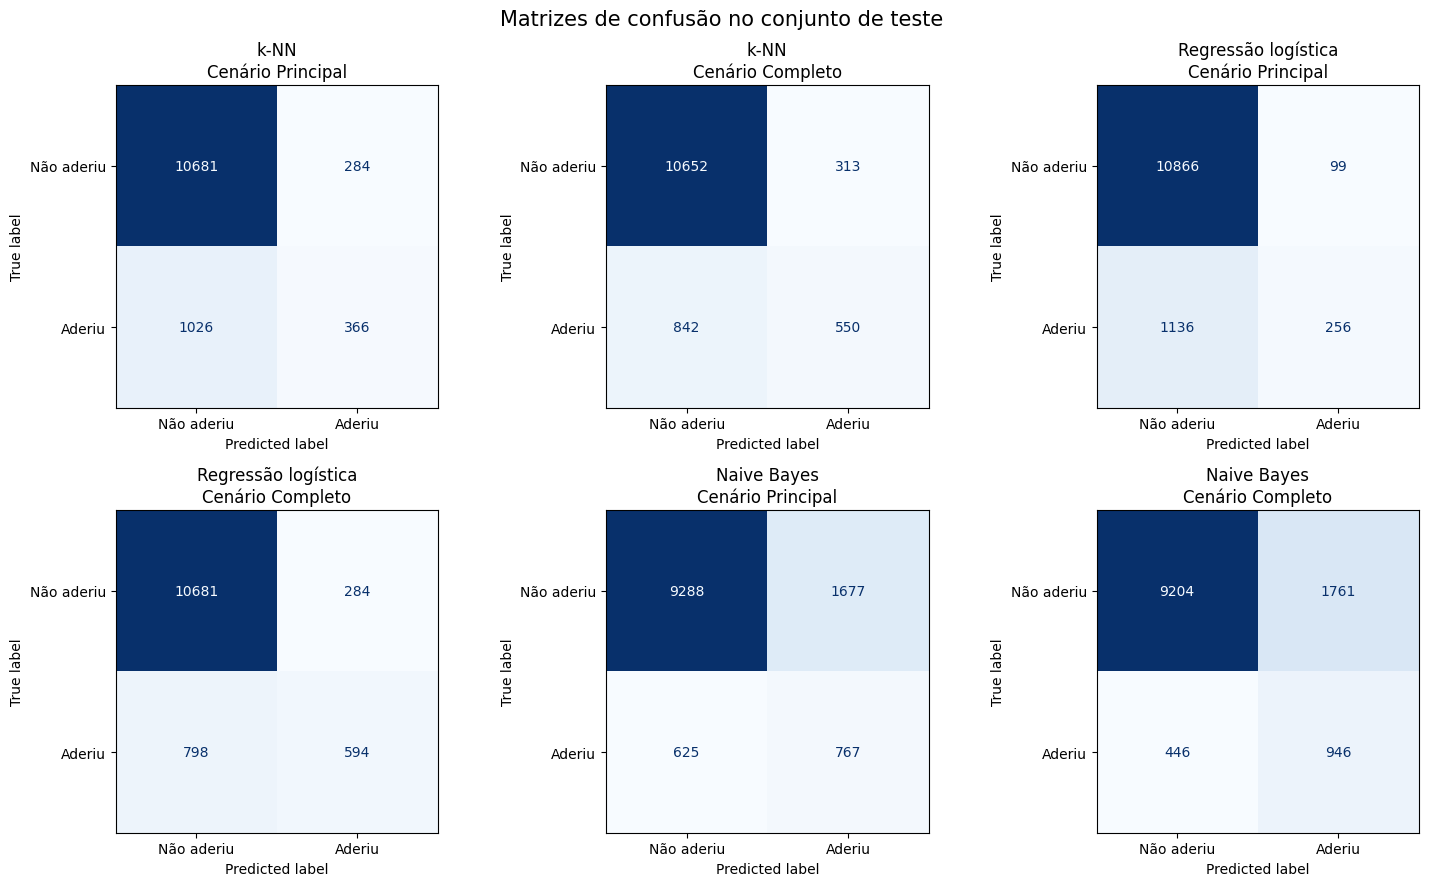

Relatórios completos por classe:

Principal — k-NN


,precision,recall,f1-score,support
Não aderiu,0.9124,0.9741,0.9422,10965.000
Aderiu,0.5631,0.2629,0.3585,1392.000
accuracy,0.8940,0.8940,0.8940,0.894
macro avg,0.7377,0.6185,0.6503,12357.000
weighted avg,0.8730,0.8940,0.8765,12357.000



Completo — k-NN


,precision,recall,f1-score,support
Não aderiu,0.9267,0.9715,0.9486,10965.0000
Aderiu,0.6373,0.3951,0.4878,1392.0000
accuracy,0.9065,0.9065,0.9065,0.9065
macro avg,0.7820,0.6833,0.7182,12357.0000
weighted avg,0.8941,0.9065,0.8967,12357.0000



Principal — Regressão logística


...

,precision,recall,f1-score,support
Não aderiu,0.9305,0.9741,0.9518,10965.0000
Aderiu,0.6765,0.4267,0.5233,1392.0000
accuracy,0.9124,0.9124,0.9124,0.9124
macro avg,0.8035,0.7004,0.7376,12357.0000
weighted avg,0.9019,0.9124,0.9035,12357.0000



Principal — Naive Bayes


,precision,recall,f1-score,support
Não aderiu,0.9370,0.8471,0.8897,10965.0000
Aderiu,0.3138,0.5510,0.3999,1392.0000
accuracy,0.8137,0.8137,0.8137,0.8137
macro avg,0.6254,0.6990,0.6448,12357.0000
weighted avg,0.8668,0.8137,0.8346,12357.0000



Completo — Naive Bayes


,precision,recall,f1-score,support
Não aderiu,0.9538,0.8394,0.8929,10965.0000
Aderiu,0.3495,0.6796,0.4616,1392.0000
accuracy,0.8214,0.8214,0.8214,0.8214
macro avg,0.6516,0.7595,0.6773,12357.0000
weighted avg,0.8857,0.8214,0.8443,12357.0000


In [28]:
resultados = pd.DataFrame(linhas_resultado)
colunas_metricas = ["acurácia", "precisão (não)", "recall (não)", "F1 (não)",
                    "precisão (sim)", "recall (sim)", "F1 (sim)",
                    "F1 CV média", "F1 CV desvio-padrão"]
display(resultados.round(4))

fig, eixos = plt.subplots(2, 3, figsize=(15, 9))
for eixo, ((nome_cenario, nome_modelo), matriz) in zip(eixos.ravel(), matrizes.items()):
    ConfusionMatrixDisplay(matriz, display_labels=["Não aderiu", "Aderiu"]).plot(
        ax=eixo, cmap="Blues", colorbar=False, values_format="d"
    )
    eixo.set_title(f"{nome_modelo}\nCenário {nome_cenario}")
fig.suptitle("Matrizes de confusão no conjunto de teste", fontsize=15)
fig.tight_layout()
plt.show()

print("Relatórios completos por classe:")
for (nome_cenario, nome_modelo), relatorio in relatorios.items():
    print(f"\n{nome_cenario} — {nome_modelo}")
    display(pd.DataFrame(relatorio).T.round(4))

## Interpretação e conclusão

O F1 de aderiu = sim é a métrica principal para comparar modelos, pois não deixa que a classe majoritária domine a avaliação e considera simultaneamente precisão e recall. Em uma campanha real, o custo de uma ligação e o valor de uma adesão também podem justificar priorizar precisão ou recall; sem esses custos definidos, o F1 é um compromisso transparente.

O cenário completo não representa uma previsão válida no instante de selecionar clientes quando usa atributos da ligação/campanha corrente. Diferenças em relação ao cenário principal servem para quantificar o efeito dessas informações posteriores, não para afirmar superioridade operacional. A validação cruzada reportada abaixo é estratificada em cinco partes sobre amostra estratificada do treino; o ajuste final usa todo o treino.

In [29]:
modelo_log_principal = modelos_finais["Principal"]["Regressão logística"]
nomes_atributos = modelo_log_principal.named_steps["preparacao"].get_feature_names_out()
coeficientes = modelo_log_principal.named_steps["modelo"].coef_[0]
top5 = pd.DataFrame({"atributo transformado": nomes_atributos, "coeficiente": coeficientes})
top5["magnitude absoluta"] = top5["coeficiente"].abs()
top5 = top5.nlargest(5, "magnitude absoluta").sort_values("magnitude absoluta", ascending=False)
print("Cinco coeficientes de maior magnitude — regressão logística, cenário principal:")
display(top5[["atributo transformado", "coeficiente"]].round(4))
print("\nLeitura dos cinco coeficientes:")
for _, linha in top5.iterrows():
    direcao = "associado a maiores" if linha["coeficiente"] > 0 else "associado a menores"
    print(f"- {linha['atributo transformado']}: {linha['coeficiente']:+.4f}, {direcao} log-odds estimadas de adesão, mantendo os demais atributos constantes.")
print("A magnitude depende da padronização/one-hot encoding; associações do modelo não implicam causalidade.")

principal = resultados[resultados["cenário"] == "Principal"].sort_values("F1 (sim)", ascending=False)
melhor = principal.iloc[0]
print(f"\nMelhor F1 de teste no cenário principal: {melhor['modelo']} "
      f"(F1={melhor['F1 (sim)']:.4f}, precisão={melhor['precisão (sim)']:.4f}, "
      f"recall={melhor['recall (sim)']:.4f}).")
print("Compare os F1 de teste ao F1 médio e ao desvio-padrão da validação cruzada na tabela única acima.")

print("\nDiferença no F1 da classe aderiu entre cenário completo e principal:")
for nome_modelo in modelos_finais["Principal"]:
    f1_principal = resultados.query("cenário == 'Principal' and modelo == @nome_modelo")["F1 (sim)"].iloc[0]
    f1_completo = resultados.query("cenário == 'Completo' and modelo == @nome_modelo")["F1 (sim)"].iloc[0]
    print(f"- {nome_modelo}: {f1_principal:.4f} -> {f1_completo:.4f} (diferença {f1_completo - f1_principal:+.4f}).")
print("O possível ganho do cenário completo deve ser interpretado com cautela: duração da ligação e atributos da campanha corrente não estão disponíveis antes da decisão de contato.")

Cinco coeficientes de maior magnitude — regressão logística, cenário principal:


,atributo transformado,coeficiente
3,taxa_variacao_emprego,-0.7095
41,resultado_campanha_anterior_fracasso,-0.6055
32,inadimplente_desconhecido,-0.5539
7,numero_empregados,-0.4409
22,estado_civil_divorciado,-0.3615



Leitura dos cinco coeficientes:
- taxa_variacao_emprego: -0.7095, associado a menores log-odds estimadas de adesão, mantendo os demais atributos constantes.
- resultado_campanha_anterior_fracasso: -0.6055, associado a menores log-odds estimadas de adesão, mantendo os demais atributos constantes.
- inadimplente_desconhecido: -0.5539, associado a menores log-odds estimadas de adesão, mantendo os demais atributos constantes.
- numero_empregados: -0.4409, associado a menores log-odds estimadas de adesão, mantendo os demais atributos constantes.
- estado_civil_divorciado: -0.3615, associado a menores log-odds estimadas de adesão, mantendo os demais atributos constantes.
A magnitude depende da padronização/one-hot encoding; associações do modelo não implicam causalidade.

Melhor F1 de teste no cenário principal: Naive Bayes (F1=0.3999, precisão=0.3138, recall=0.5510).
Compare os F1 de teste ao F1 médio e ao desvio-padrão da validação cruzada na tabela única acima.

Diferença no F1 da classe